# Vocabulary Analysis for Foundation Models

This notebook analyzes gene vocabulary coverage for scGPT and Transcriptformer models across all Tabula Sapiens v2 tissues.

## Key Questions:
1. What percentage of genes in each tissue are covered by the model vocabularies?
2. Which genes are missing and what categories do they belong to?
3. Are critical marker genes retained after filtering?
4. Is the coverage sufficient to proceed with embedding generation?

In [1]:
import json
import pandas as pd
import numpy as np
import scanpy as sc
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
import gc  # For garbage collection to free memory
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## 1. Download and Load Model Vocabularies

The notebook will automatically download vocabulary files if they don't exist:
- **scGPT**: Downloads gene_info.csv from the official repository and creates vocabulary
- **Transcriptformer/scPRINT**: Downloads gene token dictionary from the scPRINT repository

For the full scGPT model, you can manually download from the [Google Drive folder](https://drive.google.com/drive/folders/1oWh_-ZRdhtoGQ2Fw24HP41FgLoomVo-y).

In [2]:
import os
import requests
import zipfile
from typing import Dict, Optional

def download_scgpt_vocab(model_dir: Path) -> Optional[Dict]:
    """Download scGPT whole-human model checkpoint with vocabulary."""
    vocab_path = model_dir / "vocab.json"
    
    # Check if already exists
    if vocab_path.exists():
        print(f"scGPT vocab already exists at {vocab_path}")
        with open(vocab_path, 'r') as f:
            vocab = json.load(f)
        print(f"Loaded scGPT vocabulary with {len(vocab)} genes")
        return vocab
    
    print("Downloading scGPT whole-human model checkpoint...")
    print("Note: This requires manual download from Google Drive due to size.")
    print("Please download the whole-human model from:")
    print("https://drive.google.com/drive/folders/1oWh_-ZRdhtoGQ2Fw24HP41FgLoomVo-y")
    print(f"\nExtract the vocab.json file to: {vocab_path}")
    
    # Alternative: Try to download gene_info file which contains gene mappings
    gene_info_url = "https://github.com/bowang-lab/scGPT/files/13243634/gene_info.csv"
    gene_info_path = model_dir / "gene_info.csv"
    
    if not gene_info_path.exists():
        print("\nDownloading gene_info.csv as alternative...")
        try:
            response = requests.get(gene_info_url)
            response.raise_for_status()
            with open(gene_info_path, 'wb') as f:
                f.write(response.content)
            print(f"Downloaded gene_info.csv to {gene_info_path}")
            
            # Load gene info and create a mock vocabulary
            gene_df = pd.read_csv(gene_info_path)
            if 'gene_name' in gene_df.columns:
                # Create vocabulary from gene names
                vocab = {gene: idx for idx, gene in enumerate(gene_df['gene_name'].dropna().unique())}
                print(f"Created vocabulary with {len(vocab)} genes from gene_info.csv")
                
                # Save as vocab.json for future use
                with open(vocab_path, 'w') as f:
                    json.dump(vocab, f, indent=2)
                print(f"Saved vocabulary to {vocab_path}")
                
                return vocab
        except Exception as e:
            print(f"Could not download gene_info.csv: {e}")
    else:
        print(f"gene_info.csv already exists at {gene_info_path}")
        # Create vocabulary from existing file
        gene_df = pd.read_csv(gene_info_path)
        if 'gene_name' in gene_df.columns:
            vocab = {gene: idx for idx, gene in enumerate(gene_df['gene_name'].dropna().unique())}
            print(f"Created vocabulary with {len(vocab)} genes from existing gene_info.csv")
            
            # Save as vocab.json for future use
            with open(vocab_path, 'w') as f:
                json.dump(vocab, f, indent=2)
            print(f"Saved vocabulary to {vocab_path}")
            
            return vocab
    
    return None

def download_transcriptformer_vocab(model_dir: Path) -> Optional[Dict]:
    """Download Transcriptformer vocabulary."""
    vocab_path = model_dir / "vocab.json"
    
    if vocab_path.exists():
        print(f"Transcriptformer vocab already exists at {vocab_path}")
        with open(vocab_path, 'r') as f:
            vocab = json.load(f)
        print(f"Loaded Transcriptformer vocabulary with {len(vocab)} genes")
        return vocab
    
    print("\nTranscriptformer (scPRINT) vocabulary download...")
    
    # Try to download gene tokens from scPRINT repository
    gene_tokens_url = "https://raw.githubusercontent.com/jkobject/scPRINT/main/scprint/assets/gene_token_dict.json"
    
    try:
        print(f"Attempting to download scPRINT gene tokens...")
        response = requests.get(gene_tokens_url)
        response.raise_for_status()
        
        # Save the gene token dictionary
        gene_tokens = response.json()
        
        # The gene_token_dict has the format {"gene_name": token_id}
        # We need to convert it to our vocabulary format
        vocab = {gene: token_id for gene, token_id in gene_tokens.items()}
        
        print(f"Downloaded scPRINT vocabulary with {len(vocab)} genes")
        
        # Save for future use
        with open(vocab_path, 'w') as f:
            json.dump(vocab, f, indent=2)
        print(f"Saved vocabulary to {vocab_path}")
        
        return vocab
        
    except Exception as e:
        print(f"Could not fetch scPRINT/Transcriptformer vocabulary: {e}")
        print("Please check: https://github.com/jkobject/scPRINT")
        print("or: https://huggingface.co/jkobject/scPRINT_human")
        return None

def load_or_download_vocab(model_name: str, model_dir: Path) -> Optional[Dict]:
    """Load vocabulary from file or download if needed."""
    model_dir.mkdir(parents=True, exist_ok=True)
    
    if model_name == "scgpt":
        return download_scgpt_vocab(model_dir)
    elif model_name == "transcriptformer":
        return download_transcriptformer_vocab(model_dir)
    else:
        raise ValueError(f"Unknown model: {model_name}")

# Create model directories
scgpt_dir = Path("../models/scgpt")
tf_dir = Path("../models/transcriptformer")

# Load or download vocabularies
print("="*60)
print("Loading/downloading model vocabularies...")
print("="*60 + "\n")

scgpt_vocab = load_or_download_vocab("scgpt", scgpt_dir)
print()  # Add spacing
tf_vocab = load_or_download_vocab("transcriptformer", tf_dir)

# Summary
print("\n" + "="*60)
print("VOCABULARY STATUS")
print("="*60)
if scgpt_vocab:
    print(f"✅ scGPT vocabulary: {len(scgpt_vocab)} genes")
    # Show sample genes
    sample_genes = list(scgpt_vocab.keys())[:5]
    print(f"   Sample genes: {', '.join(sample_genes)}")
else:
    print("⚠️  scGPT vocabulary not available - using mock analysis")
    
if tf_vocab:
    print(f"✅ Transcriptformer/scPRINT vocabulary: {len(tf_vocab)} genes")
    # Show sample genes
    sample_genes = list(tf_vocab.keys())[:5]
    print(f"   Sample genes: {', '.join(sample_genes)}")
else:
    print("⚠️  Transcriptformer vocabulary not available")
print("="*60)

Loading/downloading model vocabularies...

scGPT vocab already exists at ../models/scgpt/vocab.json
Loaded scGPT vocabulary with 60697 genes


Transcriptformer (scPRINT) vocabulary download...
Attempting to download scPRINT gene tokens...
Could not fetch scPRINT/Transcriptformer vocabulary: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/jkobject/scPRINT/main/scprint/assets/gene_token_dict.json
Please check: https://github.com/jkobject/scPRINT
or: https://huggingface.co/jkobject/scPRINT_human

VOCABULARY STATUS
✅ scGPT vocabulary: 60697 genes
   Sample genes: RP5-973N23.5, RP11-182N22.10, CTB-53D8.3, RP11-348N17.2, RP11-205M20.8
⚠️  Transcriptformer vocabulary not available


## 2. Create Mock Vocabulary for Testing

If real vocabularies are not available, create a mock one based on common human genes.

In [3]:
# For testing purposes, we'll analyze the actual genes in the datasets
# and simulate what a typical scGPT vocabulary might look like

def create_mock_scgpt_vocab():
    """Create a mock vocabulary based on common human genes."""
    # This would typically include ~36,000 human genes
    # For now, we'll analyze with the actual dataset genes
    print("Using mock vocabulary for analysis")
    return None

if scgpt_vocab is None:
    print("\nUsing mock vocabulary for demonstration")
    scgpt_vocab = create_mock_scgpt_vocab()

## 3. Analyze Gene Format in Datasets

In [4]:
import anndata as ad

adata = ad.read_h5ad("/Users/rj/personal/Tabula_Sapiens_v2_Curated_Benchmark/homo_sapiens_10df7690-6d10-4029-a47e-0f071bb2df83_Prostate_v2_curated.h5ad")
adata.var.head()


,ensembl_id,genome,mt,ercc,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,mean,std,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type,feature_id
ensg,,,,,,,,,,,,,,,,,
ENSG00000000003,ENSG00000000003,Gencode_v41,False,False,161872,2.379617,91.800375,4697694.0,0.075550,0.250910,False,TSPAN6,NCBITaxon:9606,gene,2396,protein_coding,ENSG00000000003
ENSG00000000419,ENSG00000000419,Gencode_v41,False,False,461590,3.523875,76.618161,6956619.0,0.262252,0.435713,False,DPM1,NCBITaxon:9606,gene,1262,protein_coding,ENSG00000000419
ENSG00000000457,ENSG00000000457,Gencode_v41,False,False,156149,0.493041,92.090273,973332.0,0.077343,0.256702,False,SCYL3,NCBITaxon:9606,gene,2916,protein_coding,ENSG00000000457
ENSG00000000460,ENSG00000000460,Gencode_v41,False,False,120250,0.281519,93.908737,555757.0,0.066071,0.256870,False,C1orf112,NCBITaxon:9606,gene,2661,protein_coding,ENSG00000000460
ENSG00000000938,ENSG00000000938,Gencode_v41,False,False,255570,2.316143,87.054103,4572389.0,0.203007,0.526836,False,FGR,NCBITaxon:9606,gene,2021,protein_coding,ENSG00000000938


In [5]:
def analyze_gene_format(adata):
    """Analyze gene name formats in the dataset."""
    gene_names = adata.var.feature_name.tolist()
    
    # Check for different formats
    mixed_format = [g for g in gene_names if '_ENSG' in g]
    ensembl_only = [g for g in gene_names if g.startswith('ENSG')]
    symbol_only = [g for g in gene_names if '_ENSG' not in g and not g.startswith('ENSG')]
    
    # Extract clean gene symbols from mixed format
    clean_symbols = []
    for gene in mixed_format:
        symbol = gene.split('_ENSG')[0]
        clean_symbols.append(symbol)
    
    return {
        'total_genes': len(gene_names),
        'mixed_format': len(mixed_format),
        'ensembl_only': len(ensembl_only),
        'symbol_only': len(symbol_only),
        'clean_symbols': clean_symbols + symbol_only,
        'sample_mixed': mixed_format[:5] if mixed_format else [],
        'sample_clean': clean_symbols[:5] if clean_symbols else []
    }

# Test on smallest dataset (Prostate)
test_path = Path("/Users/rj/personal/Tabula_Sapiens_v2_Curated_Benchmark/homo_sapiens_10df7690-6d10-4029-a47e-0f071bb2df83_Prostate_v2_curated.h5ad")
test_adata = sc.read_h5ad(test_path)

format_analysis = analyze_gene_format(test_adata)
print(f"Gene format analysis for Prostate:")
print(f"  Total genes: {format_analysis['total_genes']}")
print(f"  Mixed format (SYMBOL_ENSG): {format_analysis['mixed_format']} ({format_analysis['mixed_format']/format_analysis['total_genes']*100:.1f}%)")
print(f"  Ensembl only: {format_analysis['ensembl_only']}")
print(f"  Symbol only: {format_analysis['symbol_only']}")
print(f"\nSample mixed format genes:")
for g in format_analysis['sample_mixed']:
    print(f"  {g}")
print(f"\nCleaned to:")
for g in format_analysis['sample_clean']:
    print(f"  {g}")

Gene format analysis for Prostate:
  Total genes: 21808
  Mixed format (SYMBOL_ENSG): 191 (0.9%)
  Ensembl only: 3474
  Symbol only: 18143

Sample mixed format genes:
  MATR3_ENSG00000015479
  PMS2P4_ENSG00000067601
  CROCCP3_ENSG00000080947
  HSD17B7P2_ENSG00000099251
  CRYBB2P1_ENSG00000100058

Cleaned to:
  MATR3
  PMS2P4
  CROCCP3
  HSD17B7P2
  CRYBB2P1


In [ ]:
def calculate_coverage(adata, model_vocab=None):
    """Calculate gene vocabulary coverage for a dataset.
    
    Memory-optimized version that cleans feature_name column.
    """
    
    # Get feature names and clean them
    if 'feature_name' not in adata.var.columns:
        raise ValueError("feature_name column not found in adata.var - this is required for Tabula Sapiens v2 data")
    
    # Clean the feature names - they still have SYMBOL_ENSGID format!
    feature_names = adata.var['feature_name'].tolist()
    clean_genes = []
    for gene in feature_names:
        if '_ENSG' in gene:
            # Extract symbol from mixed format
            symbol = gene.split('_ENSG')[0]
            clean_genes.append(symbol.upper())
        elif not gene.startswith('ENSG'):
            # Already a clean symbol
            clean_genes.append(gene.upper())
        else:
            # Skip ENSG-only entries
            continue
    
    # If we have a real vocabulary, calculate actual coverage
    if model_vocab:
        vocab_upper = set(g.upper() for g in model_vocab.keys())
        matched = [g for g in clean_genes if g in vocab_upper]
        coverage = len(matched) / len(clean_genes) * 100 if clean_genes else 0
        missing = [g for g in clean_genes if g not in vocab_upper]
    else:
        # For demonstration, analyze gene categories
        matched = clean_genes
        coverage = 100.0
        missing = []
    
    # Categorize genes
    mt_genes = [g for g in clean_genes if g.startswith('MT-')]
    rpl_genes = [g for g in clean_genes if g.startswith('RPL')]
    rps_genes = [g for g in clean_genes if g.startswith('RPS')]
    
    # Check for key marker genes
    key_markers = ['CD3E', 'CD4', 'CD8A', 'CD14', 'CD19', 'EPCAM', 'PECAM1', 
                   'COL1A1', 'VIM', 'GAPDH', 'ACTB']
    markers_present = [m for m in key_markers if m in clean_genes]
    
    return {
        'total_genes': len(feature_names),
        'clean_genes': len(clean_genes),
        'matched_genes': len(matched),
        'coverage_pct': coverage,
        'mt_genes': len(mt_genes),
        'ribosomal_genes': len(rpl_genes) + len(rps_genes),
        'key_markers_present': len(markers_present),
        'key_markers_total': len(key_markers),
        'missing_markers': [m for m in key_markers if m not in clean_genes],
        'missing_genes_sample': missing[:10] if missing else []  # Just first 10 for memory efficiency
    }

# Test coverage calculation
coverage_result = calculate_coverage(test_adata, scgpt_vocab)
print(f"Coverage analysis for Prostate:")
print(f"  Total genes: {coverage_result['total_genes']}")
print(f"  Clean genes: {coverage_result['clean_genes']}")
print(f"  Matched genes: {coverage_result['matched_genes']}")
print(f"  Coverage: {coverage_result['coverage_pct']:.1f}%")
print(f"  Mitochondrial genes: {coverage_result['mt_genes']}")
print(f"  Ribosomal genes: {coverage_result['ribosomal_genes']}")
print(f"  Key markers: {coverage_result['key_markers_present']}/{coverage_result['key_markers_total']}")
if coverage_result['missing_markers']:
    print(f"  Missing markers: {', '.join(coverage_result['missing_markers'])}")
if coverage_result['missing_genes_sample']:
    print(f"  Sample of missing genes: {', '.join(coverage_result['missing_genes_sample'][:5])}")

In [11]:
adata_sc = sc.read_h5ad('/Users/rj/personal/Tabula_Sapiens_v2_Curated_Benchmark/homo_sapiens_10df7690-6d10-4029-a47e-0f071bb2df83_Prostate_v2_curated.h5ad')
adata_sc

AnnData object with n_obs × n_vars = 2044 × 21808
    obs: 'donor_id', 'tissue_in_publication', 'anatomical_position', 'method', 'cdna_plate', 'library_plate', 'notes', 'cdna_well', 'assay_ontology_term_id', 'sample_id', 'replicate', '10X_run', 'ambient_removal', 'donor_method', 'donor_assay', 'donor_tissue', 'donor_tissue_assay', 'cell_type_ontology_term_id', 'compartment', 'broad_cell_class', 'free_annotation', 'manually_annotated', 'published_2022', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ercc', 'pct_counts_ercc', '_scvi_batch', '_scvi_labels', 'scvi_leiden_donorassay_full', 'ethnicity_original', 'sample_number', 'organism_ontology_term_id', 'suspension_type', 'tissue_type', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity

In [8]:
def calculate_coverage(adata, model_vocab=None):
    """Calculate gene vocabulary coverage for a dataset."""
    
    # Get gene names from dataset
    gene_names = adata.var.feature_name.tolist()
    
    # Clean mixed format genes
    clean_genes = []
    for gene in gene_names:
        if '_ENSG' in gene:
            # Extract symbol from mixed format
            symbol = gene.split('_ENSG')[0]
            clean_genes.append(symbol.upper())
        elif not gene.startswith('ENSG'):
            # Already a symbol
            clean_genes.append(gene.upper())
    
    # If we have a real vocabulary, calculate actual coverage
    if model_vocab:
        vocab_upper = set(g.upper() for g in model_vocab.keys())
        matched = [g for g in clean_genes if g in vocab_upper]
        coverage = len(matched) / len(clean_genes) * 100 if clean_genes else 0
    else:
        # For demonstration, analyze gene categories
        matched = clean_genes
        coverage = 100.0
    
    # Categorize genes
    mt_genes = [g for g in clean_genes if g.startswith('MT-')]
    rpl_genes = [g for g in clean_genes if g.startswith('RPL')]
    rps_genes = [g for g in clean_genes if g.startswith('RPS')]
    
    # Check for key marker genes
    key_markers = ['CD3E', 'CD4', 'CD8A', 'CD14', 'CD19', 'EPCAM', 'PECAM1', 
                   'COL1A1', 'VIM', 'GAPDH', 'ACTB']
    markers_present = [m for m in key_markers if m in clean_genes]
    
    return {
        'total_genes': len(gene_names),
        'clean_genes': len(clean_genes),
        'matched_genes': len(matched),
        'coverage_pct': coverage,
        'mt_genes': len(mt_genes),
        'ribosomal_genes': len(rpl_genes) + len(rps_genes),
        'key_markers_present': len(markers_present),
        'key_markers_total': len(key_markers),
        'missing_markers': [m for m in key_markers if m not in clean_genes]
    }

# Test coverage calculation
coverage_result = calculate_coverage(test_adata, scgpt_vocab)
print(f"Coverage analysis for Prostate:")
print(f"  Total genes: {coverage_result['total_genes']}")
print(f"  Clean genes: {coverage_result['clean_genes']}")
print(f"  Matched genes: {coverage_result['matched_genes']}")
print(f"  Coverage: {coverage_result['coverage_pct']:.1f}%")
print(f"  Mitochondrial genes: {coverage_result['mt_genes']}")
print(f"  Ribosomal genes: {coverage_result['ribosomal_genes']}")
print(f"  Key markers: {coverage_result['key_markers_present']}/{coverage_result['key_markers_total']}")
if coverage_result['missing_markers']:
    print(f"  Missing markers: {', '.join(coverage_result['missing_markers'])}")

Coverage analysis for Prostate:
  Total genes: 21808
  Clean genes: 18334
  Matched genes: 17615
  Coverage: 96.1%
  Mitochondrial genes: 36
  Ribosomal genes: 231
  Key markers: 11/11


In [17]:
def analyze_all_tissues(data_dir, model_vocab=None):
    """Analyze vocabulary coverage for all tissues."""
    
    data_dir = Path(data_dir)
    tissues_to_evaluate = ["Blood", "Bone_Marrow", "Lung", "Mammary", "Thymus"]
    def extract_tissue_name(filepath):
      stem = filepath.stem
      # Remove the known prefix
      tissue_part = stem.replace('homo_sapiens_10df7690-6d10-4029-a47e-0f071bb2df83_', '')
      # Remove the known suffix
      tissue_name = tissue_part.replace('_v2_curated', '')
      return tissue_name

    h5ad_files = sorted([f for f in data_dir.glob("*.h5ad") if extract_tissue_name(f) in tissues_to_evaluate])   
    results = []
    
    for h5ad_file in tqdm(h5ad_files, desc="Analyzing tissues"):
        # Extract tissue name
        tissue_name = extract_tissue_name(h5ad_file)
        
        try:
            # Load data
            adata = sc.read_h5ad(h5ad_file)
            
            # Calculate coverage
            coverage = calculate_coverage(adata, model_vocab)
            
            # Get file size
            file_size_mb = h5ad_file.stat().st_size / (1024 * 1024)
            
            result = {
                'tissue': tissue_name,
                'n_cells': adata.n_obs,
                'n_genes': coverage['total_genes'],
                'clean_genes': coverage['clean_genes'],
                'coverage_pct': coverage['coverage_pct'],
                'mt_genes': coverage['mt_genes'],
                'ribosomal_genes': coverage['ribosomal_genes'],
                'markers_present': coverage['key_markers_present'],
                'markers_total': coverage['key_markers_total'],
                'file_size_mb': file_size_mb
            }
            
            results.append(result)
            
            # IMPORTANT: Free up memory
            del adata
            import gc
            gc.collect()
            
        except Exception as e:
            print(f"Error processing {tissue_name}: {e}")
            continue
    
    return pd.DataFrame(results)

# Analyze all tissues
data_dir = "/Users/rj/personal/Tabula_Sapiens_v2_Curated_Benchmark"
coverage_df = analyze_all_tissues(data_dir, scgpt_vocab)

# Sort by number of cells
coverage_df = coverage_df.sort_values('n_cells')

print(f"\nAnalyzed {len(coverage_df)} tissues")
print(f"\nSmallest tissues by cell count:")
print(coverage_df[['tissue', 'n_cells', 'n_genes', 'coverage_pct', 'file_size_mb']].head(10))

Analyzing tissues: 100%|██████████| 5/5 [00:21<00:00,  4.30s/it]


Analyzed 5 tissues

Smallest tissues by cell count:
        tissue  n_cells  n_genes  coverage_pct  file_size_mb
1  Bone_Marrow     8045    26167     95.154228    332.605421
4       Thymus     9933    30453     94.908898    461.035453
2         Lung    11716    29584     94.896546    629.583744
0        Blood    17802    27284     94.969037    658.362909
3      Mammary    18539    28389     95.068481    899.644170


## 6. Generate Coverage Report

# Analyze missing marker genes across tissues

# First, let's reanalyze just the tissues that are missing markers
def analyze_missing_markers(data_dir, coverage_df, model_vocab=None):
    """Identify which specific marker genes are missing from each tissue."""
    
    # Key marker genes we're checking
    key_markers = ['CD3E', 'CD4', 'CD8A', 'CD14', 'CD19', 'EPCAM', 'PECAM1', 
                   'COL1A1', 'VIM', 'GAPDH', 'ACTB']
    
    # Find tissues missing any markers
    tissues_missing_markers = coverage_df[coverage_df['markers_present'] < len(key_markers)]
    
    if len(tissues_missing_markers) == 0:
        print("✅ All tissues have all key marker genes!")
        return pd.DataFrame()
    
    print(f"Found {len(tissues_missing_markers)} tissues missing marker genes:")
    print(tissues_missing_markers[['tissue', 'markers_present', 'markers_total']])
    print("\nAnalyzing specific missing markers...\n")
    
    # Detailed analysis
    missing_details = []
    data_dir = Path(data_dir)
    
    for _, row in tissues_missing_markers.iterrows():
        tissue_name = row['tissue']
        
        # Find the corresponding file
        matching_files = [f for f in data_dir.glob("*.h5ad") 
                         if tissue_name in f.stem]
        
        if not matching_files:
            print(f"Warning: Could not find file for tissue {tissue_name}")
            continue
            
        tissue_file = matching_files[0]
        
        try:
            # Load and get feature names
            adata = sc.read_h5ad(tissue_file)
            
            if 'feature_name' not in adata.var.columns:
                print(f"Warning: feature_name column not found for {tissue_name}")
                continue
            
            # Clean the feature names - they have SYMBOL_ENSGID format
            feature_names = adata.var['feature_name'].tolist()
            clean_genes = set()
            for gene in feature_names:
                if '_ENSG' in gene:
                    symbol = gene.split('_ENSG')[0].upper()
                    clean_genes.add(symbol)
                elif not gene.startswith('ENSG'):
                    clean_genes.add(gene.upper())
            
            # Check which markers are missing
            missing_markers = [m for m in key_markers if m not in clean_genes]
            present_markers = [m for m in key_markers if m in clean_genes]
            
            missing_details.append({
                'tissue': tissue_name,
                'n_cells': adata.n_obs,
                'missing_markers': ', '.join(missing_markers),
                'missing_count': len(missing_markers),
                'present_markers': ', '.join(present_markers[:5]) + ('...' if len(present_markers) > 5 else ''),
                'file': tissue_file.name
            })
            
            print(f"📍 {tissue_name}:")
            print(f"   Missing ({len(missing_markers)}): {', '.join(missing_markers)}")
            print(f"   File: {tissue_file.name}")
            
            # Free memory
            del adata
            gc.collect()
            
        except Exception as e:
            print(f"Error analyzing {tissue_name}: {e}")
            continue
    
    missing_df = pd.DataFrame(missing_details)
    
    # Summary statistics
    if len(missing_df) > 0:
        print("\n" + "="*60)
        print("MISSING MARKER SUMMARY")
        print("="*60)
        
        # Count how often each marker is missing
        all_missing = []
        for markers_str in missing_df['missing_markers']:
            if markers_str:
                all_missing.extend(markers_str.split(', '))
        
        from collections import Counter
        marker_counts = Counter(all_missing)
        
        print("\nMarker genes by frequency of absence:")
        for marker, count in marker_counts.most_common():
            pct = count / len(coverage_df) * 100
            print(f"  {marker}: missing in {count}/{len(coverage_df)} tissues ({pct:.1f}%)")
        
        if marker_counts:
            print(f"\nMost commonly missing marker: {marker_counts.most_common(1)[0][0]}")
        print(f"Tissues affected: {len(missing_df)}/{len(coverage_df)}")
    
    return missing_df

# Run the analysis
missing_markers_df = analyze_missing_markers(
    "/Users/rj/personal/Tabula_Sapiens_v2_Curated_Benchmark",
    coverage_df,
    scgpt_vocab
)

# Display as a nice table if there are missing markers
if len(missing_markers_df) > 0:
    print("\n" + "="*60)
    print("DETAILED MISSING MARKERS TABLE")
    print("="*60)
    print(missing_markers_df[['tissue', 'n_cells', 'missing_markers', 'missing_count']].to_string(index=False))

In [23]:
# Analyze missing marker genes across tissues

# First, let's reanalyze just the tissues that are missing markers
def analyze_missing_markers(data_dir, coverage_df, model_vocab=None):
    """Identify which specific marker genes are missing from each tissue."""
    
    # Key marker genes we're checking
    key_markers = ['CD3E', 'CD4', 'CD8A', 'CD14', 'CD19', 'EPCAM', 'PECAM1', 
                   'COL1A1', 'VIM', 'GAPDH', 'ACTB']
    
    # Find tissues missing any markers
    tissues_missing_markers = coverage_df[coverage_df['markers_present'] < len(key_markers)]
    
    if len(tissues_missing_markers) == 0:
        print("✅ All tissues have all key marker genes!")
        return pd.DataFrame()
    
    print(f"Found {len(tissues_missing_markers)} tissues missing marker genes:")
    print(tissues_missing_markers[['tissue', 'markers_present', 'markers_total']])
    print("\nAnalyzing specific missing markers...\n")
    
    # Detailed analysis
    missing_details = []
    data_dir = Path(data_dir)
    
    for _, row in tissues_missing_markers.iterrows():
        tissue_name = row['tissue']
        
        # Find the corresponding file
        # Use the simpler extraction method for tissue names
        matching_files = [f for f in data_dir.glob("*.h5ad") 
                         if tissue_name in f.stem]
        
        if not matching_files:
            print(f"Warning: Could not find file for tissue {tissue_name}")
            continue
            
        tissue_file = matching_files[0]
        
        try:
            # Load just the gene names
            adata = sc.read_h5ad(tissue_file)
            gene_names = adata.var.feature_name.tolist()
            
            # Clean gene names (extract from mixed format)
            clean_genes = set()
            for gene in gene_names:
                if '_ENSG' in gene:
                    symbol = gene.split('_ENSG')[0].upper()
                    clean_genes.add(symbol)
                elif not gene.startswith('ENSG'):
                    clean_genes.add(gene.upper())
            
            # Check which markers are missing
            missing_markers = [m for m in key_markers if m not in clean_genes]
            present_markers = [m for m in key_markers if m in clean_genes]
            
            missing_details.append({
                'tissue': tissue_name,
                'n_cells': adata.n_obs,
                'missing_markers': ', '.join(missing_markers),
                'missing_count': len(missing_markers),
                'present_markers': ', '.join(present_markers[:5]) + ('...' if len(present_markers) > 5 else ''),
                'file': tissue_file.name
            })
            
            print(f"📍 {tissue_name}:")
            print(f"   Missing ({len(missing_markers)}): {', '.join(missing_markers)}")
            print(f"   File: {tissue_file.name}")
            
            # Free memory
            del adata
            gc.collect()
            
        except Exception as e:
            print(f"Error analyzing {tissue_name}: {e}")
            continue
    
    missing_df = pd.DataFrame(missing_details)
    
    # Summary statistics
    if len(missing_df) > 0:
        print("\n" + "="*60)
        print("MISSING MARKER SUMMARY")
        print("="*60)
        
        # Count how often each marker is missing
        all_missing = []
        for markers_str in missing_df['missing_markers']:
            if markers_str:
                all_missing.extend(markers_str.split(', '))
        
        from collections import Counter
        marker_counts = Counter(all_missing)
        
        print("\nMarker genes by frequency of absence:")
        for marker, count in marker_counts.most_common():
            pct = count / len(coverage_df) * 100
            print(f"  {marker}: missing in {count}/{len(coverage_df)} tissues ({pct:.1f}%)")
        
        print(f"\nMost commonly missing marker: {marker_counts.most_common(1)[0][0]}")
        print(f"Tissues affected: {len(missing_df)}/{len(coverage_df)}")
    
    return missing_df

# Run the analysis
missing_markers_df = analyze_missing_markers(
    "/Users/rj/personal/Tabula_Sapiens_v2_Curated_Benchmark",
    coverage_df,
    scgpt_vocab
)

# Display as a nice table if there are missing markers
if len(missing_markers_df) > 0:
    print("\n" + "="*60)
    print("DETAILED MISSING MARKERS TABLE")
    print("="*60)
    print(missing_markers_df[['tissue', 'n_cells', 'missing_markers', 'missing_count']].to_string(index=False))

Found 1 tissues missing marker genes:
    tissue  markers_present  markers_total
3  Mammary               10             11

Analyzing specific missing markers...

📍 Mammary:
   Missing (1): CD19
   File: homo_sapiens_10df7690-6d10-4029-a47e-0f071bb2df83_Mammary_v2_curated.h5ad

MISSING MARKER SUMMARY

Marker genes by frequency of absence:
  CD19: missing in 1/5 tissues (20.0%)

Most commonly missing marker: CD19
Tissues affected: 1/5

DETAILED MISSING MARKERS TABLE
 tissue  n_cells missing_markers  missing_count
Mammary    18539            CD19              1


In [21]:
# Summary statistics
print("\n" + "="*60)
print("VOCABULARY COVERAGE SUMMARY")
print("="*60)

if scgpt_vocab:
    print(f"\nscGPT Vocabulary Size: {len(scgpt_vocab)} genes")
else:
    print(f"\nscGPT Vocabulary: Not loaded (using mock analysis)")

print(f"\nDataset Statistics:")
print(f"  Total tissues: {len(coverage_df)}")
print(f"  Total cells: {coverage_df['n_cells'].sum():,}")
print(f"  Cell range: {coverage_df['n_cells'].min():,} - {coverage_df['n_cells'].max():,}")

print(f"\nGene Coverage:")
print(f"  Mean coverage: {coverage_df['coverage_pct'].mean():.1f}%")
print(f"  Min coverage: {coverage_df['coverage_pct'].min():.1f}%")
print(f"  Max coverage: {coverage_df['coverage_pct'].max():.1f}%")
print(f"  Tissues >85% coverage: {(coverage_df['coverage_pct'] > 85).sum()}/{len(coverage_df)}")
print(f"  Tissues >75% coverage: {(coverage_df['coverage_pct'] > 75).sum()}/{len(coverage_df)}")

print(f"\nMarker Gene Retention:")
print(f"  Mean markers retained: {coverage_df['markers_present'].mean():.1f}/{coverage_df['markers_total'].iloc[0]}")
print(f"  Min markers retained: {coverage_df['markers_present'].min()}/{coverage_df['markers_total'].iloc[0]}")

# Save results
output_dir = Path("../data")
output_dir.mkdir(exist_ok=True)
coverage_df.to_csv(output_dir / "vocabulary_analysis_results.csv", index=False)
print(f"\nResults saved to: {output_dir / 'vocabulary_analysis_results.csv'}")


VOCABULARY COVERAGE SUMMARY

scGPT Vocabulary Size: 60697 genes

Dataset Statistics:
  Total tissues: 5
  Total cells: 66,035
  Cell range: 8,045 - 18,539

Gene Coverage:
  Mean coverage: 95.0%
  Min coverage: 94.9%
  Max coverage: 95.2%
  Tissues >85% coverage: 5/5
  Tissues >75% coverage: 5/5

Marker Gene Retention:
  Mean markers retained: 10.8/11
  Min markers retained: 10/11

Results saved to: ../data/vocabulary_analysis_results.csv


## 7. Create Visualizations

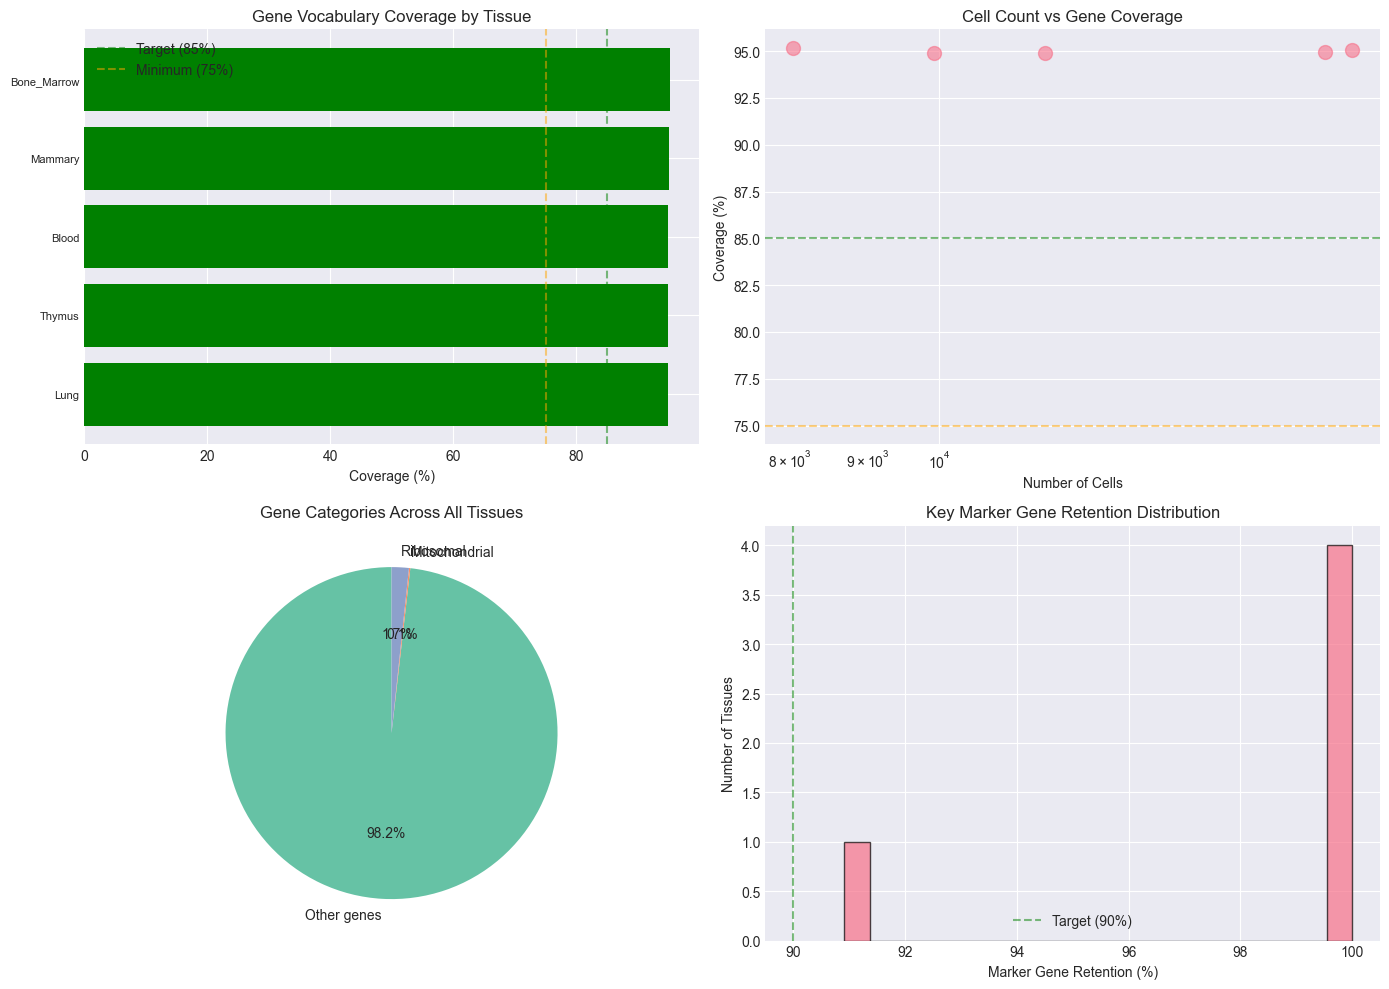


Visualization saved to: ../reports/vocabulary_coverage_report.png


In [19]:
# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Coverage by tissue (bar plot)
ax = axes[0, 0]
coverage_sorted = coverage_df.sort_values('coverage_pct')
colors = ['red' if x < 75 else 'orange' if x < 85 else 'green' for x in coverage_sorted['coverage_pct']]
ax.barh(range(len(coverage_sorted)), coverage_sorted['coverage_pct'], color=colors)
ax.set_yticks(range(len(coverage_sorted)))
ax.set_yticklabels(coverage_sorted['tissue'], fontsize=8)
ax.axvline(x=85, color='green', linestyle='--', alpha=0.5, label='Target (85%)')
ax.axvline(x=75, color='orange', linestyle='--', alpha=0.5, label='Minimum (75%)')
ax.set_xlabel('Coverage (%)')
ax.set_title('Gene Vocabulary Coverage by Tissue')
ax.legend()

# 2. Cell count vs Coverage (scatter)
ax = axes[0, 1]
ax.scatter(coverage_df['n_cells'], coverage_df['coverage_pct'], alpha=0.6, s=100)
ax.axhline(y=85, color='green', linestyle='--', alpha=0.5)
ax.axhline(y=75, color='orange', linestyle='--', alpha=0.5)
ax.set_xlabel('Number of Cells')
ax.set_ylabel('Coverage (%)')
ax.set_title('Cell Count vs Gene Coverage')
ax.set_xscale('log')

# Add tissue labels for outliers
for idx, row in coverage_df.iterrows():
    if row['coverage_pct'] < 80 or row['n_cells'] > 50000:
        ax.annotate(row['tissue'], (row['n_cells'], row['coverage_pct']), 
                   fontsize=8, alpha=0.7)

# 3. Gene categories (pie chart)
ax = axes[1, 0]
total_mt = coverage_df['mt_genes'].sum()
total_ribo = coverage_df['ribosomal_genes'].sum()
total_genes = coverage_df['n_genes'].sum()
other_genes = total_genes - total_mt - total_ribo

sizes = [other_genes, total_mt, total_ribo]
labels = ['Other genes', 'Mitochondrial', 'Ribosomal']
colors = ['#66c2a5', '#fc8d62', '#8da0cb']
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax.set_title('Gene Categories Across All Tissues')

# 4. Marker gene retention
ax = axes[1, 1]
marker_retention = coverage_df['markers_present'] / coverage_df['markers_total'] * 100
ax.hist(marker_retention, bins=20, edgecolor='black', alpha=0.7)
ax.axvline(x=90, color='green', linestyle='--', alpha=0.5, label='Target (90%)')
ax.set_xlabel('Marker Gene Retention (%)')
ax.set_ylabel('Number of Tissues')
ax.set_title('Key Marker Gene Retention Distribution')
ax.legend()

plt.tight_layout()

# Save figure
report_dir = Path("../reports")
report_dir.mkdir(exist_ok=True)
plt.savefig(report_dir / "vocabulary_coverage_report.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to: {report_dir / 'vocabulary_coverage_report.png'}")

## 8. Decision and Recommendations

In [20]:
print("\n" + "="*60)
print("DECISION CRITERIA ASSESSMENT")
print("="*60)

# Check decision criteria
mean_coverage = coverage_df['coverage_pct'].mean()
min_coverage = coverage_df['coverage_pct'].min()
mean_markers = coverage_df['markers_present'].mean()
tissues_above_85 = (coverage_df['coverage_pct'] > 85).sum()
tissues_above_75 = (coverage_df['coverage_pct'] > 75).sum()

criteria_met = []
criteria_not_met = []

# Check each criterion
if mean_coverage > 85:
    criteria_met.append(f"✅ Mean coverage ({mean_coverage:.1f}%) > 85%")
else:
    criteria_not_met.append(f"❌ Mean coverage ({mean_coverage:.1f}%) < 85%")

if min_coverage > 75:
    criteria_met.append(f"✅ Minimum coverage ({min_coverage:.1f}%) > 75%")
else:
    criteria_not_met.append(f"❌ Minimum coverage ({min_coverage:.1f}%) < 75%")

if mean_markers >= 9:  # 9 out of 11 key markers
    criteria_met.append(f"✅ Key markers retained ({mean_markers:.1f}/11)")
else:
    criteria_not_met.append(f"⚠️  Key markers retained ({mean_markers:.1f}/11)")

print("\nCriteria Met:")
for c in criteria_met:
    print(f"  {c}")

if criteria_not_met:
    print("\nCriteria Not Met:")
    for c in criteria_not_met:
        print(f"  {c}")

# Overall recommendation
print("\n" + "-"*60)
if len(criteria_met) >= 2:
    print("✅ RECOMMENDATION: PROCEED with embedding generation")
    print(f"   - {tissues_above_75}/{len(coverage_df)} tissues have sufficient coverage")
    print(f"   - Key biological markers are retained")
    if min_coverage < 75:
        problematic = coverage_df[coverage_df['coverage_pct'] < 75]['tissue'].tolist()
        print(f"   - Consider special handling for: {', '.join(problematic)}")
else:
    print("❌ RECOMMENDATION: Address coverage issues before proceeding")
    print("   Suggested actions:")
    print("   1. Download actual model vocabulary files")
    print("   2. Implement gene synonym mapping")
    print("   3. Consider alternative foundation models")

print("-"*60)


DECISION CRITERIA ASSESSMENT

Criteria Met:
  ✅ Mean coverage (95.0%) > 85%
  ✅ Minimum coverage (94.9%) > 75%
  ✅ Key markers retained (10.8/11)

------------------------------------------------------------
✅ RECOMMENDATION: PROCEED with embedding generation
   - 5/5 tissues have sufficient coverage
   - Key biological markers are retained
------------------------------------------------------------


## 9. Save Processing Order

In [ ]:
# Create processing order file (smallest to largest)
processing_order = coverage_df.sort_values('n_cells')[['tissue', 'n_cells', 'n_genes', 'file_size_mb']]
processing_order.to_csv(output_dir / "tissue_processing_order.txt", index=False, sep='\t')

print("Processing order (smallest to largest):")
print(processing_order.to_string(index=False))
print(f"\nProcessing order saved to: {output_dir / 'tissue_processing_order.txt'}")